# Escuela Politécnica Nacional
## Métodos Numericos
#### Erick Cuichan 
#### Tarea 7

---

- 1. Dado los puntos (0,1), (1,5), (2,3), determine el spline cúbico.

### Datos
$$
x_0=0,\quad x_1=1,\quad x_2=2
$$

$$
y_0=1,\quad y_1=5,\quad y_2=3
$$

### Coeficientes para cada tramo 

$$
a_0=1,\quad b_0=5.5,\quad c_0=0,\quad d_0=-1.5
$$

$$
a_1=5,\quad b_1=1,\quad c_1=-4.5,\quad d_1=1.5
$$


### Primer tramo

$$
S_0(x)=1+5.5(x-0)+0(x-0)^2-1.5(x-0)^3
$$

Simplificando:

$$
S_0(x)=1+5.5x-1.5x^3
$$

### Segundo tramo

$$
S_1(x)=5+1(x-1)-4.5(x-1)^2+1.5(x-1)^3
$$

##  Ecuación final 

$$
S(x)=
\begin{cases}
1+5.5x-1.5x^3, & 0 \leq x \leq 1 \\[6pt]
5+(x-1)-4.5(x-1)^2+1.5(x-1)^3, & 1 \leq x \leq 2
\end{cases}
$$

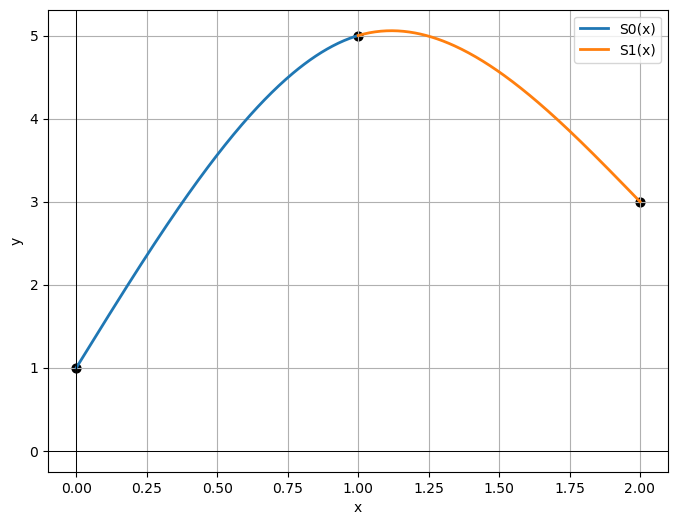

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def spline_cubico_natural(x, y):

    m = len(x) - 1

    h = [x[i+1] - x[i] for i in range(m)]
    alpha = [0]*m
    for i in range(1, m):
        alpha[i] = (3/h[i])*(y[i+1] - y[i]) - (3/h[i-1])*(y[i] - y[i-1])

    L = [0]*(m+1)
    mu = [0]*(m+1)
    z = [0]*(m+1)

    L[0] = 1
    mu[0] = 0
    z[0] = 0

    for i in range(1, m):
        L[i] = 2*(x[i+1] - x[i-1]) - h[i-1]*mu[i-1]
        mu[i] = h[i] / L[i]
        z[i] = (alpha[i] - h[i-1]*z[i-1]) / L[i]

    L[m] = 1
    z[m] = 0

    c = [0]*(m+1)
    b = [0]*m
    d = [0]*m

    for j in range(m-1, -1, -1):
        c[j] = z[j] - mu[j]*c[j+1]
        b[j] = (y[j+1] - y[j])/h[j] - (h[j]*(c[j+1] + 2*c[j]))/3
        d[j] = (c[j+1] - c[j]) / (3*h[j])

    return y, b, c, d


x = [0, 1, 2]
y = [1, 5, 3]

a, b, c, d = spline_cubico_natural(x, y)

plt.figure(figsize=(8,6))

for i in range(len(x)-1):
    Xseg = np.linspace(x[i], x[i+1], 200)
    Yseg = a[i] + b[i]*(Xseg - x[i]) + c[i]*(Xseg - x[i])**2 + d[i]*(Xseg - x[i])**3
    plt.plot(Xseg, Yseg, label=f"S{i}(x)", linewidth=2,)

for xi, yi in zip(x, y):
    plt.scatter(xi, yi, color="#000000", s=40)

plt.axhline(0, color='black', linewidth=0.7)
plt.axvline(0, color='black', linewidth=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


---

- 2. Dado los puntos (-1,1), (1,3), determine el spline cúbico sabiendo que $ f'(x_0) = 1, f'(x_n) = 2 $

### 1. Datos

$$
x_0=-1,\quad x_1=1
$$

$$
y_0=1,\quad y_1=3
$$

$$
f'(x_0)=1,\quad f'(x_1)=2
$$

### 2. Forma  del spline


$$
S_0(x)=a_0+b_0(x-x_0)+c_0(x-x_0)^2+d_0(x-x_0)^3
$$



$$
x_0=-1
$$



$$
x-x_0=x-(-1)=x+1
$$

$$
S_0(x)=a_0+b_0(x+1)+c_0(x+1)^2+d_0(x+1)^3
$$

### 3. Reemplazo de condiciones

Como el spline pasa por el primer punto:

$$
S_0(-1)=1
$$

$$
a_0=1
$$

$$
S_0'(-1)=1
$$

entonces:

$$
b_0=1
$$


$$
S_0(x)=1+1(x+1)+c_0(x+1)^2+d_0(x+1)^3
$$

Otro punto:

$$
S_0(1)=3
$$

Sustituyendo:

$$
1+1(1+1)+c_0(1+1)^2+d_0(1+1)^3=3
$$

$$
1+2+4c_0+8d_0=3
$$

$$
4c_0+8d_0=0
$$

Derivada final:

$$
S_0'(1)=2
$$

$$
S_0'(x)=1+2c_0(x+1)+3d_0(x+1)^2
$$

Sustituyendo \(x=1\):

$$
1+2c_0(2)+3d_0(2)^2=2
$$


$$
4c_0+12d_0=1
$$



### 4. Spline cúbico final

Los coeficientes son:

$$
a_0=1,\quad b_0=1,\quad c_0=-\frac{1}{2},\quad d_0=\frac{1}{4}
$$

Entonces:

$$
S_0(x)=1+(x+1)-\frac{1}{2}(x+1)^2+\frac{1}{4}(x+1)^3
$$


### 5. Ecuación final

$$
S(x)=1+(x+1)-\frac{1}{2}(x+1)^2+\frac{1}{4}(x+1)^3,
\quad -1 \leq x \leq 1
$$

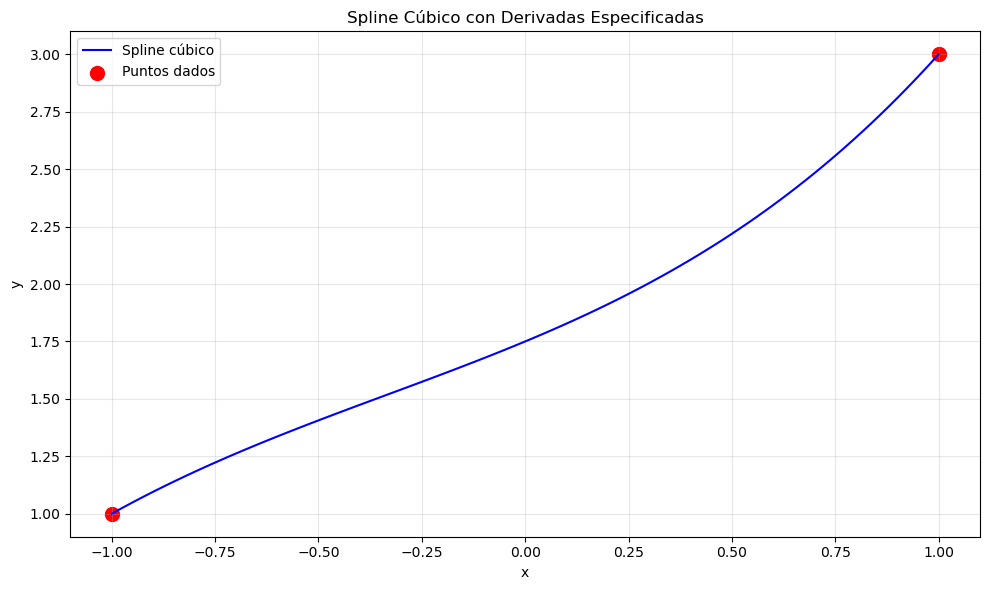


Ecuación del spline cúbico:
S(x) = 1.00 + 1.00(x+1) + -0.50(x+1)^2 + 0.25(x+1)^3


In [6]:
x = np.array([-1, 1])
y = np.array([1, 3])
derivadas = np.array([1, 2]) 

a, b, c, d = 1, 1, -0.5, 0.25

def S(x_val):
    return a + b*(x_val + 1) + c*(x_val + 1)**2 + d*(x_val + 1)**3

def S_prime(x_val):
    return b + 2*c*(x_val + 1) + 3*d*(x_val + 1)**2

x_vals = np.linspace(-1, 1, 100)
y_vals = S(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', label='Spline cúbico')
plt.scatter(x, y, color='red', s=100, label='Puntos dados')

plt.title('Spline Cúbico con Derivadas Especificadas')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


print("\nEcuación del spline cúbico:")
print(f"S(x) = {a:.2f} + {b:.2f}(x+1) + {c:.2f}(x+1)^2 + {d:.2f}(x+1)^3")

---

- 3. Diríjase al pseudocódigo del spline cúbico con frontera natural provisto en clase, en base a ese pseudocódigo complete la siguiente función:

In [ ]:
import sympy as sym
from IPython.display import display

def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:

    points = sorted(zip(xs, ys), key=lambda x: x[0])
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    
    n = len(points) - 1  
    h = [xs[i+1] - xs[i] for i in range(n)]  
    
    alpha = [0] * (n+1)
    for i in range(1, n):
        alpha[i] = (3/h[i])*(ys[i+1]-ys[i]) - (3/h[i-1])*(ys[i]-ys[i-1])
    
    l = [1.0] 
    mu = [0.0]  
    z = [0.0]   
    
    for i in range(1, n):
        l.append(2*(xs[i+1]-xs[i-1]) - h[i-1]*mu[i-1])
        mu.append(h[i]/l[i])
        z.append((alpha[i] - h[i-1]*z[i-1])/l[i])
    
    l.append(1.0)
    z.append(0.0)
    c = [0.0]*(n+1)
    
    for i in range(n-1, -1, -1):
        c[i] = z[i] - mu[i]*c[i+1]
    
    x = sym.Symbol('x')
    splines = []
    
    for j in range(n):
        a = ys[j]
        b = (ys[j+1]-ys[j])/h[j] - h[j]*(c[j+1]+2*c[j])/3
        d = (c[j+1]-c[j])/(3*h[j])
        
        S = a + b*(x-xs[j]) + c[j]*(x-xs[j])**2 + d*(x-xs[j])**3
        splines.append(S)
    
    return splines

In [9]:
xs = [1, 2, 3]
ys = [-5, -4, 3]

splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]
print("______")
_ = [display(s.expand()) for s in splines]

-0.5*x + 1.5*(x - 1)**3 - 4.5

4.0*x - 1.5*(x - 2)**3 + 4.5*(x - 2)**2 - 12.0

______


1.5*x**3 - 4.5*x**2 + 4.0*x - 6.0

-1.5*x**3 + 13.5*x**2 - 32.0*x + 18.0

---

- 4. Usando la función anterior, encuentre el spline cúbico para:

$ xs = [1, 2, 3] $

$ ys = [2, 3, 5] $

Intervalo [1, 2]:
 Sj(x) = 2 + 0.75(x-1) + 0.0(x-1)^2 + 0.25(x-1)^3
Intervalo [2, 3]:
 Sj(x) = 3 + 1.5(x-2) + 0.75(x-2)^2 + -0.25(x-2)^3


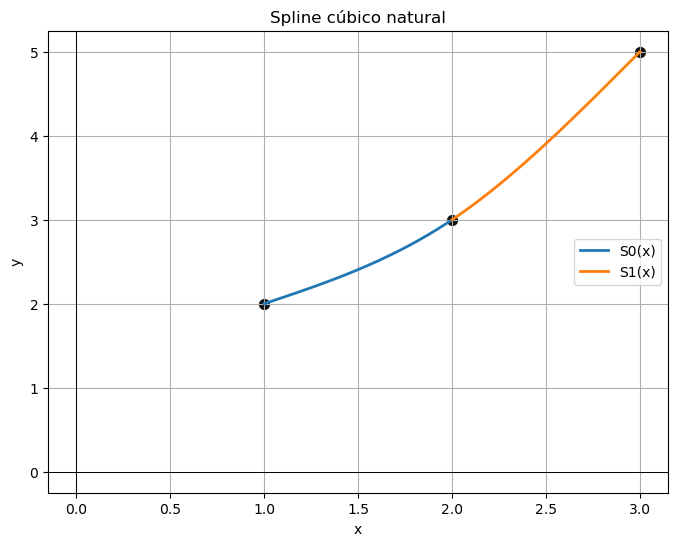

In [12]:
def spline_cubico_natural(x, a):
 
    n = len(x) - 1

    h = [0]*(n)
    for i in range(n):
        h[i] = x[i+1] - x[i]

    alpha = [0]*(n)
    for i in range(1, n):
        alpha[i] = (3/h[i])*(a[i+1] - a[i]) - (3/h[i-1])*(a[i] - a[i-1])

    l = [0]*(n+1)
    mu = [0]*(n+1)
    z = [0]*(n+1)

    l[0] = 1
    mu[0] = 0
    z[0] = 0

    for i in range(1, n):
        l[i] = 2*(x[i+1] - x[i-1]) - h[i-1]*mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1]*z[i-1]) / l[i]

    l[n] = 1
    z[n] = 0
    c = [0]*(n+1)
    c[n] = 0

    b = [0]*n
    d = [0]*n

    for j in range(n-1, -1, -1):
        c[j] = z[j] - mu[j]*c[j+1]
        b[j] = (a[j+1] - a[j])/h[j] - h[j]*(c[j+1] + 2*c[j])/3
        d[j] = (c[j+1] - c[j]) / (3*h[j])

    return a, b, c, d

x = [1, 2, 3]
y = [2, 3, 5]

a, b, c, d = spline_cubico_natural(x, y)

for j in range(len(x)-1):
    print(f"Intervalo [{x[j]}, {x[j+1]}]:")
    print(f" Sj(x) = {a[j]} + {b[j]}(x-{x[j]}) + {c[j]}(x-{x[j]})^2 + {d[j]}(x-{x[j]})^3")


plt.figure(figsize=(8,6))

for j in range(len(x)-1):
    xs = np.linspace(x[j], x[j+1], 200)
    ys = a[j] + b[j]*(xs-x[j]) + c[j]*(xs-x[j])**2 + d[j]*(xs-x[j])**3
    plt.plot(xs, ys, label=f"S{j}(x)", linewidth=2)

plt.scatter(x, y, color="#131112", s=50)

plt.axhline(0, color='black', linewidth=0.7)
plt.axvline(0, color='black', linewidth=0.7)
plt.grid(True)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spline cúbico natural")
plt.show()

---

- 5. Usando la función anterior, encuentre el spline cúbico para:

$ xs = [0, 1, 2, 3] $

$ ys = [-1, 1, 5, 2] $

Intervalo [0, 1]:
 Sj(x) = -1 + 1.0(x-0) + 0.0(x-0)^2 + 1.0(x-0)^3
Intervalo [1, 2]:
 Sj(x) = 1 + 4.0(x-1) + 3.0(x-1)^2 + -3.0(x-1)^3
Intervalo [2, 3]:
 Sj(x) = 5 + 1.0(x-2) + -6.0(x-2)^2 + 2.0(x-2)^3


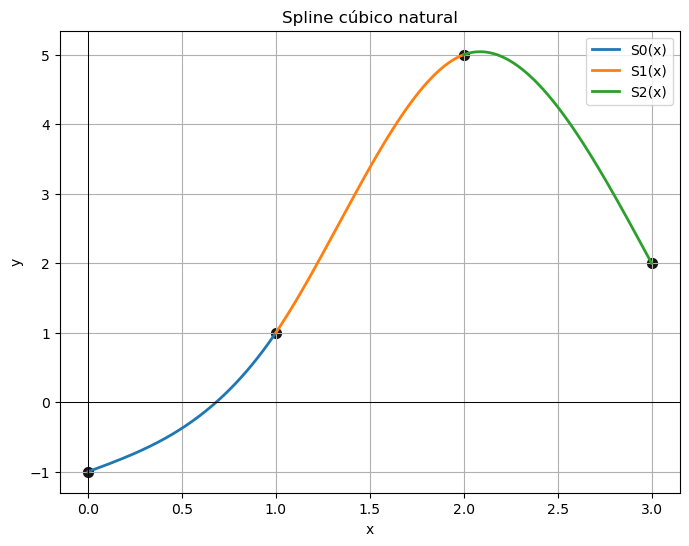

In [13]:
def spline_cubico_natural(x, a):
 
    n = len(x) - 1

 
    h = [0]*(n)
    for i in range(n):
        h[i] = x[i+1] - x[i]


    alpha = [0]*(n)
    for i in range(1, n):
        alpha[i] = (3/h[i])*(a[i+1] - a[i]) - (3/h[i-1])*(a[i] - a[i-1])


    l = [0]*(n+1)
    mu = [0]*(n+1)
    z = [0]*(n+1)

    l[0] = 1
    mu[0] = 0
    z[0] = 0

    for i in range(1, n):
        l[i] = 2*(x[i+1] - x[i-1]) - h[i-1]*mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1]*z[i-1]) / l[i]
    l[n] = 1
    z[n] = 0
    c = [0]*(n+1)
    c[n] = 0
    
    b = [0]*n
    d = [0]*n

    for j in range(n-1, -1, -1):
        c[j] = z[j] - mu[j]*c[j+1]
        b[j] = (a[j+1] - a[j])/h[j] - h[j]*(c[j+1] + 2*c[j])/3
        d[j] = (c[j+1] - c[j]) / (3*h[j])


    return a, b, c, d

x = [0, 1, 2, 3]
y = [-1, 1, 5, 2]

a, b, c, d = spline_cubico_natural(x, y)

for j in range(len(x)-1):
    print(f"Intervalo [{x[j]}, {x[j+1]}]:")
    print(f" Sj(x) = {a[j]} + {b[j]}(x-{x[j]}) + {c[j]}(x-{x[j]})^2 + {d[j]}(x-{x[j]})^3")
    

plt.figure(figsize=(8,6))

for j in range(len(x)-1):
    xs = np.linspace(x[j], x[j+1], 200)
    ys = a[j] + b[j]*(xs-x[j]) + c[j]*(xs-x[j])**2 + d[j]*(xs-x[j])**3
    plt.plot(xs, ys, label=f"S{j}(x)", linewidth=2)

plt.scatter(x, y, color="#191213", s=50)

plt.axhline(0, color='black', linewidth=0.7)
plt.axvline(0, color='black', linewidth=0.7)
plt.grid(True)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spline cúbico natural")
plt.show()

 

 

---

- 6. Use la función cubic_spline_clamped, prvista en el enlance de Github, para practicar los datos de la siguiente tabla.

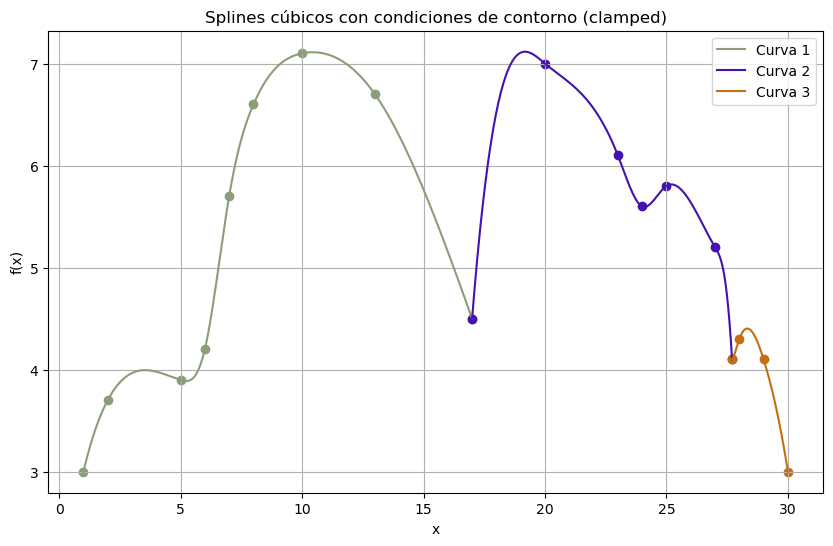

In [15]:
import numpy as np
import matplotlib.pyplot as plt


def spline_cubico_clamped(x, a, FPO, FPN):

    n = len(x) - 1
    h = [x[i+1] - x[i] for i in range(n)]

    alpha = [0]*(n+1)
    alpha[0] = 3*((a[1]-a[0])/h[0] - FPO)
    alpha[n] = 3*(FPN - (a[n]-a[n-1])/h[n-1])

    for i in range(1, n):
        alpha[i] = 3/h[i]*(a[i+1]-a[i]) - 3/h[i-1]*(a[i]-a[i-1])

    l = [0]*(n+1)
    mu = [0]*(n+1)
    z = [0]*(n+1)

    l[0] = 2*h[0]
    mu[0] = 0.5
    z[0] = alpha[0] / l[0]

    for i in range(1, n):
        l[i] = 2*(x[i+1]-x[i-1]) - h[i-1]*mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1]*z[i-1]) / l[i]

    l[n] = h[n-1]*(2 - mu[n-1])
    z[n] = (alpha[n] - h[n-1]*z[n-1]) / l[n]

    c = [0]*(n+1)
    c[n] = z[n]
    b = [0]*n
    d = [0]*n

    for j in range(n-1, -1, -1):
        c[j] = z[j] - mu[j]*c[j+1]
        b[j] = (a[j+1]-a[j])/h[j] - h[j]*(c[j+1] + 2*c[j]) / 3
        d[j] = (c[j+1]-c[j]) / (3*h[j])

    return a[:-1], b, c[:-1], d


x1 = [1,2,5,6,7,8,10,13,17]
y1 = [3.0,3.7,3.9,4.2,5.7,6.6,7.1,6.7,4.5]
fp1 = [1.0, -0.67] 


x2 = [17,20,23,24,25,27,27.7]
y2 = [4.5,7.0,6.1,5.6,5.8,5.2,4.1]
fp2 = [3.0, -4.0]


x3 = [27.7,28,29,30]
y3 = [4.1,4.3,4.1,3.0]
fp3 = [0.33, -1.5]



def eval_spline(x, a, b, c, d, X):
    Y = []
    for xq in X:
        for j in range(len(a)):
            if x[j] <= xq <= x[j+1]:
                dx = xq - x[j]
                yq = a[j] + b[j]*dx + c[j]*dx**2 + d[j]*dx**3
                Y.append(yq)
                break
    return np.array(Y)



plt.figure(figsize=(10,6))

for x, y, fp, color, label in [
    (x1, y1, fp1, "#8C9D7A", "Curva 1"),
    (x2, y2, fp2, "#4412AF", "Curva 2"),
    (x3, y3, fp3, "#C56F12", "Curva 3")
]:
    a,b,c,d = spline_cubico_clamped(x, y, fp[0], fp[1])

    Xq = np.linspace(min(x), max(x), 200)
    Yq = eval_spline(x, a, b, c, d, Xq)

    plt.plot(Xq, Yq, color=color, label=label)
    plt.scatter(x, y, color=color)


plt.title("Splines cúbicos con condiciones de contorno (clamped)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()
